In [36]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Аналитическое решение с использованием SymPy

In [37]:
x, p, a, hbar = sp.symbols('x p a hbar', real=True, positive=True)
n = sp.Symbol('n', integer=True, positive=True)

psi_x = sp.sqrt(2/a) * sp.sin(sp.pi * n * x / a)

# Подынтегральное выражение
integrand = psi_x * sp.exp(-sp.I * p * x / hbar) / sp.sqrt(2 * sp.pi * hbar)

# Вычисление интеграла
phi_p = sp.integrate(integrand, (x, 0, a)).simplify()

# Вычисление плотности вероятности |Phi(p)|^2
prob_density_p = sp.simplify(sp.trigsimp((phi_p * sp.conjugate(phi_p))))

In [38]:
phi_p

Piecewise((sqrt(pi)*sqrt(a)*hbar**(3/2)*n*((-1)**n - exp(I*a*p/hbar))*exp(-I*a*p/hbar)/(a**2*p**2 - pi**2*hbar**2*n**2), Ne(a, pi*hbar*n/p)), ((-a*p*(-sin(a*p/hbar) + I*cos(a*p/hbar)) + hbar*exp(I*a*p/hbar) - hbar*cos(a*p/hbar))*exp(-I*a*p/hbar)/(2*sqrt(pi)*sqrt(a)*sqrt(hbar)*p), True))

In [39]:
prob_density_p

Piecewise((pi*a*hbar**3*n**2*((-1)**n - exp(I*a*p/hbar))*((-1)**n*exp(I*a*p/hbar) - 1)*exp(-I*a*p/hbar)/(a**2*p**2 - pi**2*hbar**2*n**2)**2, Ne(a, pi*hbar*n/p)), ((hbar + (a*p*(sin(a*p/hbar) + I*cos(a*p/hbar)) - hbar*cos(a*p/hbar))*exp(I*a*p/hbar))*(a*p*(sin(a*p/hbar) - I*cos(a*p/hbar)) + hbar*exp(I*a*p/hbar) - hbar*cos(a*p/hbar))*exp(-I*a*p/hbar)/(4*pi*a*hbar*p**2), True))

# График плотности вероятности

In [40]:
a_my = 6.6*1e-34
hbar_my = 6.6*1e-34
n_my = 1

In [41]:
# Параметры системы: a = 1, hbar = 1, основное состояние n = 1
params = {a: a_my, hbar: hbar_my, n: n_my}
prob_density_num = prob_density_p.subs(params)

prob_func = sp.lambdify(p, prob_density_num, 'numpy')

p_vals = np.linspace(-np.pi * hbar_my * n_my /a_my*3, np.pi * hbar_my * n_my /a_my*3, 1000)
prob_vals = np.real(prob_func(p_vals))

<lambdifygenerated-10>:2: RuntimeWarning: divide by zero encountered in divide
  return select([not_equal(6.6e-34*pi/p, 6.6e-34),True], [1.8974736e-133*pi*(-exp(1.0*1j*p) - 1)**2*exp(-1.0*1j*p)/(4.356e-67*p**2 - 4.356e-67*pi**2)**2,5.73921028466483e+65*((6.6e-34*p*(sin(1.0*p) + 1j*cos(1.0*p)) - 6.6e-34*cos(1.0*p))*exp(1.0*1j*p) + 6.6e-34)*(6.6e-34*p*(sin(1.0*p) - 1j*cos(1.0*p)) + 6.6e-34*exp(1.0*1j*p) - 6.6e-34*cos(1.0*p))*exp(-1.0*1j*p)/(pi*p**2)], default=nan)


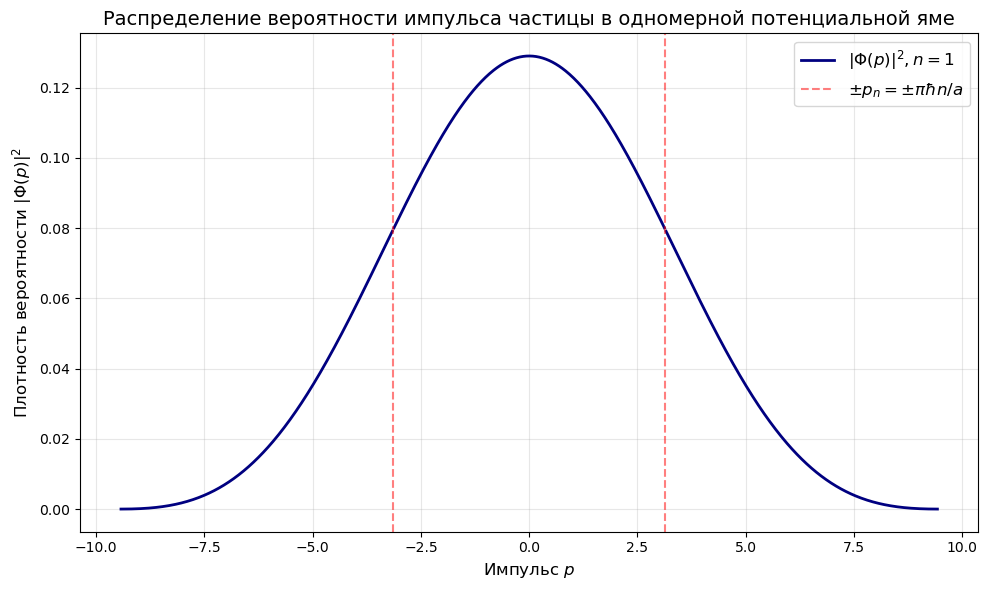

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(p_vals, prob_vals, color='navy', lw=2, label=r'$|\Phi(p)|^2, n=1$')
plt.title('Распределение вероятности импульса частицы в одномерной потенциальной яме', fontsize=14)
plt.xlabel(r'Импульс $p$', fontsize=12)
plt.ylabel(r'Плотность вероятности $|\Phi(p)|^2$', fontsize=12)
plt.axvline(x=np.pi * hbar_my * n_my /a_my, color='red', linestyle='--', alpha=0.5, label=rf'$\pm p_{n} = \pm \pi\hbar n/a$')
plt.axvline(x=-np.pi * hbar_my * n_my /a_my, color='red', linestyle='--', alpha=0.5)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()